# Inventory Control with RL

This notebook illustrates a complete and minimal workflow to train RL inventory-control agents, evaluate them, and register the persisted models.

## Controlled System: SKU (Stock Keeping Unit)
The inventory system consists of a single SKU with stochastic demand and stochastic lead times.

The state contains on-hand inventory and an in-transit order pipeline; actions are replenishment quantities selected by a reinforcement learning (RL) policy.

The reward is computed from one-step operating cost (ordering cost, holding cost, and lost-sales cost), and episodes are truncated after a fixed number of days.

Main model/experiment parameters:
- `Lmax`: pipeline length / maximum lead time.
- `demand_spec`: demand distribution used by the environment.
- `lead_time_weights`: probability weights for lead times over `1..Lmax`.
- `K_fix`, `v`, `h`, `p`: fixed ordering cost, variable ordering cost per unit, holding cost, and lost-sales cost.
- `N_days`: episode length used for training/evaluation.
- `RUNS`: number of independent training replicas per configuration.


## Objective

We will train three algorithms on the same SKU:
- `DQN` with discrete actions.
- `SAC` with continuous actions.
- `PPO` with discrete actions.

The service workflow is always the same:
1. `train_agent(...)`
2. `evaluate_agent(...)`
3. `register_agent(...)`

At the end we will compare the aggregated learning curves of all three algorithms.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

CANDIDATES = [Path.cwd().resolve(), Path.cwd().resolve().parent]
ROOT = next((candidate for candidate in CANDIDATES if (candidate / 'control_rl').exists()), None)
if ROOT is None:
    raise RuntimeError('Could not locate repo root containing control_rl')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from control_rl.agents import evaluate_agent, get_learning_curves, register_agent, train_agent


## Problem Parameters

The `ENV_CONFIG` configuration describes the SKU, demand, lead times, and costs used by the environment.


In [2]:
SKU_ID = 'sku_001'
REGISTRY_ROOT = ROOT / 'artifacts' / 'sku_registry'
TRAINED_MODELS_ROOT = ROOT / 'artifacts' / 'trained_models'
SKU_MODELS_DIR = TRAINED_MODELS_ROOT / SKU_ID
PLOTS_DIR = SKU_MODELS_DIR / 'comparison'

TOTAL_TIMESTEPS = 5_000
SEED = 123
RUNS = 5
EVAL_FREQ = 250
EVAL_EPISODES = 5
LEARNING_CURVE_SMOOTH_WINDOW = 3
CONF_Z = 1.697

BASE_TRAINING_CONFIG = {
    'n_replicas': RUNS,
    'base_seed': SEED,
    'total_timesteps': TOTAL_TIMESTEPS,
    'eval_freq': EVAL_FREQ,
    'n_eval_episodes': EVAL_EPISODES,
    'output_dir': str(SKU_MODELS_DIR),
}

ENV_CONFIG = {
    'Lmax': 3,
    'demand_spec': {
        'kind': 'normal_clipped',
        'mean': 8.5,
        'std': 2.0,
        'low': 0.0,
        'high': 20.0,
    },
    'lead_time_weights': [0.5, 0.35, 0.15],
    'q_min': 0.0,
    'q_max': 40.0,
    'K_fix': 8.0,
    'v': 1.0,
    'h': 0.15,
    'p': 6.0,
    'max_steps': 30,
}


## Algorithm Configuration

`DQN` and `PPO` use discrete actions, while `SAC` uses continuous actions. Each configuration defines the action mode together with the relevant SB3 hyperparameters.


In [23]:
dqn_algo_config = {
    'action_mode': 'discrete',
    'action_step': 1.0,
    'learning_rate': 5e-4,
    'buffer_size': 8_000,
    'batch_size': 128,
    'gamma': 0.99,
    'learning_starts': 200,
    'train_freq': 4,
    'target_update_interval': 250,
}

sac_algo_config = {
    'action_mode': 'continuous',
    'learning_rate': 3e-4,
    'buffer_size': 5_000,
    'batch_size': 128,
    'learning_starts': 500,
    'tau': 0.005,
    'gamma': 0.99,
}

ppo_algo_config = {
    'action_mode': 'discrete',
    'action_step': 1.0,
    'learning_rate': 3e-4,
    'n_steps': 128,
    'batch_size': 64,
    'n_epochs': 4,
    'gamma': 0.99,
    'gae_lambda': 0.95,
    'clip_range': 0.2,
    'ent_coef': 0.01,
}


## API Used in the Workflow

- `train_agent(...)`: trains the model and saves the run artifacts.
- `evaluate_agent(...)`: loads the trained model and computes KPIs on a common scenario.
- `register_agent(...)`: persists the agent in the SKU registry.
- `get_learning_curves(...)`: retrieves the evaluation curves for each replica.


In [4]:
def run_agent_workflow(*, algorithm_name: str, algorithm_config: dict[str, float | str | int]) -> dict[str, object]:
    training_result = train_agent(
        env_config=ENV_CONFIG,
        algorithm_name=algorithm_name,
        algorithm_config=algorithm_config,
        training_config=BASE_TRAINING_CONFIG,
    )
    evaluation_result = evaluate_agent(
        training_result=training_result,
        env_config=ENV_CONFIG,
        algorithm_name=algorithm_name,
        algorithm_config=algorithm_config,
        base_seed=SEED,
    )
    agent_metadata = register_agent(
        registry=REGISTRY_ROOT,
        sku_id=SKU_ID,
        env_config=ENV_CONFIG,
        algorithm_name=algorithm_name,
        algorithm_config=algorithm_config,
        training_result=training_result,
        training_config=BASE_TRAINING_CONFIG,
        overwrite=True,
    )
    return {
        'training_result': training_result,
        'evaluation_result': evaluation_result,
        'agent_metadata': agent_metadata,
    }


## Training and Registering Agents

This cell runs the complete workflow for `DQN`, `SAC`, and `PPO`.


In [24]:
dqn_result = run_agent_workflow(
    algorithm_name='DQN',
    algorithm_config=dqn_algo_config,
)
print('DQN agent training complete')

sac_result = run_agent_workflow(
    algorithm_name='SAC',
    algorithm_config=sac_algo_config,
)
print('SAC agent training complete')

ppo_result = run_agent_workflow(
    algorithm_name='PPO',
    algorithm_config=ppo_algo_config,
)
print('PPO agent training complete')

print('DQN agent:', dqn_result['agent_metadata']['agent_id'])
print('SAC agent:', sac_result['agent_metadata']['agent_id'])
print('PPO agent:', ppo_result['agent_metadata']['agent_id'])


DQN agent training complete
SAC agent training complete
PPO agent training complete
DQN agent: dqn_171964e8
SAC agent: sac_c62a2e37
PPO agent: ppo_16dc9d30


## Quick Evaluation Summary

We show a compact view of the aggregate KPIs returned by `evaluate_agent(...)`.


In [25]:
dqn_result['evaluation_result']['aggregate_summary'], sac_result['evaluation_result']['aggregate_summary'], ppo_result['evaluation_result']['aggregate_summary']


({'n_replicas': 20,
  'replica_mean': 9.5,
  'total_cost_mean': 409.4147003075044,
  'ordering_cost_mean': 237.1,
  'holding_cost_mean': 100.52177820558393,
  'lost_sales_cost_mean': 71.79292210192051,
  'fill_rate_mean': 0.9532888902590095,
  'total_lost_sales_mean': 11.965487016986751,
  'avg_inventory_mean': 22.3381729345742,
  'n_orders_mean': 5.55,
  'stockout_count_mean': 2.4,
  'n_days_mean': 30.0},
 {'n_replicas': 20,
  'replica_mean': 9.5,
  'total_cost_mean': 546.6397666224706,
  'ordering_cost_mean': 441.9294963002205,
  'holding_cost_mean': 96.49991121115666,
  'lost_sales_cost_mean': 8.210359111093405,
  'fill_rate_mean': 0.99487130010568,
  'total_lost_sales_mean': 1.3683931851822344,
  'avg_inventory_mean': 21.444424713590372,
  'n_orders_mean': 30.0,
  'stockout_count_mean': 0.55,
  'n_days_mean': 30.0},
 {'n_replicas': 20,
  'replica_mean': 9.5,
  'total_cost_mean': 577.444345172381,
  'ordering_cost_mean': 274.45,
  'holding_cost_mean': 94.05286011184515,
  'lost_sale

## Learning Curves

The curves are aggregated across replicas and displayed with a simple confidence band.


In [26]:
def aggregate_curve_runs(curve_list: list[tuple[np.ndarray, np.ndarray]]) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    common_steps = np.asarray(curve_list[0][0], dtype=float)
    stacked = []
    for steps, rewards in curve_list:
        steps = np.asarray(steps, dtype=float)
        rewards = np.asarray(rewards, dtype=float)
        if not np.array_equal(steps, common_steps):
            rewards = np.interp(common_steps, steps, rewards)
        stacked.append(rewards)
    mat = np.vstack(stacked)
    r_mean = np.nanmean(mat, axis=0)
    r_std = np.nanstd(mat, axis=0, ddof=1 if mat.shape[0] > 1 else 0)
    return common_steps, r_mean, r_std

def smooth_series(values: np.ndarray, window: int) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    w = int(window)
    if w <= 1 or values.size < w:
        return values
    if w % 2 == 0:
        w += 1
    half = w // 2
    kernel = np.ones(w, dtype=float) / float(w)
    padded = np.pad(values, (half, half), mode='edge')
    return np.convolve(padded, kernel, mode='valid')

dqn_curve_list = get_learning_curves(dqn_result['training_result'])
sac_curve_list = get_learning_curves(sac_result['training_result'])
ppo_curve_list = get_learning_curves(ppo_result['training_result'])

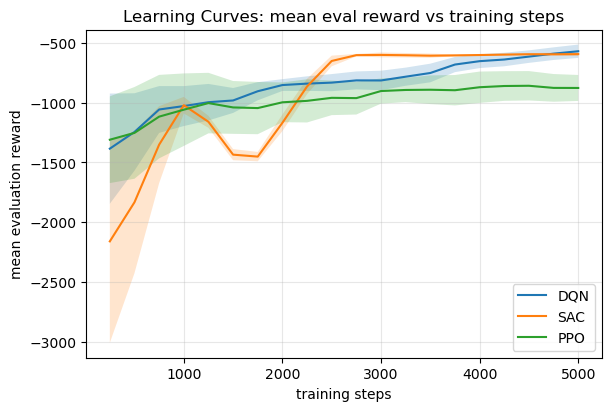

In [27]:
fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
for name, curve_list in [('DQN', dqn_curve_list), ('SAC', sac_curve_list), ('PPO', ppo_curve_list)]:
    steps, r_mean, r_std = aggregate_curve_runs(curve_list)
    r_mean_plot = smooth_series(r_mean, LEARNING_CURVE_SMOOTH_WINDOW)
    r_std_plot = smooth_series(r_std, LEARNING_CURVE_SMOOTH_WINDOW)
    margin = CONF_Z * r_std_plot / np.sqrt(RUNS)
    ax.plot(steps, r_mean_plot, label=name)
    ax.fill_between(steps, r_mean_plot - margin, r_mean_plot + margin, alpha=0.2)

ax.set_title('Learning Curves: mean eval reward vs training steps')
ax.set_xlabel('training steps')
ax.set_ylabel('mean evaluation reward')
ax.grid(True, alpha=0.3)
ax.legend(loc='best')
plt.show()


## Result

The notebook leaves the three agents registered and shows their aggregated learning curves. From here you can also compare their KPIs or load the persisted agents from the registry.
